## Hypothesis

행동 공간이 11개로 증가하더라도 constant ε=0.1이 가장 좋은 성능을 보일 것이다. 행동 후보가 많아지면 무작위 탐험에서 특정한 좋은 행동을 선택할 확률이 1/11로 감소하기 때문에, 높은 ε를 유지하는 전략은 비효율적인 행동을 더 자주 선택할 수 있다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
class CarEnv:
    def __init__(self, reward_type="A"):
        self.m = 1000.0
        self.dt = 0.1
        self.force_scale = 1000.0
        self.target = 10.0
        self.reward_type = reward_type

        self.x = 0.0
        self.v = 0.0
        self.previous_distance = 0.0
        self.current_distance = 0.0
        self.error = self.target - self.x

    def reset(self):
        self.x = 0.0
        self.v = 0.0
        self.previous_distance = abs(self.target - self.x)
        self.current_distance = abs(self.target - self.x)
        self.error = self.target - self.x
        return np.array([self.x, self.v])

    def step(self, action):
        self.previous_distance = abs(self.target - self.x)

        F = action * self.force_scale
        a = F / self.m

        self.v = self.v + a * self.dt
        self.x = self.x + self.v * self.dt
        self.error = self.target - self.x
        self.current_distance = abs(self.target - self.x)

        next_state = np.array([self.x, self.v])
        done = self.x >= self.target

        reward = self.calculate_reward(
            self.previous_distance,
            self.current_distance,
            done
        )

        return next_state, reward, done

    def calculate_reward(self, prev_distance, new_distance, done):
        if self.reward_type == "A":
            reward = -new_distance

        elif self.reward_type == "B":
            if new_distance < prev_distance:
                reward = 1
            else:
                reward = -1

        elif self.reward_type == "C":
            if done:
                reward = 100
            else:
                reward = -1

        elif self.reward_type == "D":
            reward = -new_distance

            if new_distance < prev_distance:
                reward += 1
            elif new_distance > prev_distance:
                reward -= 1

            if done:
                reward += 100

        else:
            raise ValueError("reward_type must be one of: A, B, C, D")

        return reward

In [3]:
actions = np.linspace(-1.0, 1.0, 11)

def discretize_state(state):
    x_bin = int(state[0])
    v_bin = int(state[1])
    return (x_bin, v_bin)

def get_q_values(Q, state, actions):
    if state not in Q:
        Q[state] = [0.0] * len(actions)
    return Q[state]

def select_action(Q, state, epsilon, actions):
    if random.random() < epsilon:
        action_index = np.random.choice(len(actions))
    else:
        q_values = get_q_values(Q, state, actions)
        action_index = q_values.index(max(q_values))

    action = actions[action_index]
    return action, action_index

def update_q(Q, state, action_idx, reward, next_state, alpha, gamma, actions, done):

    if done:
        target = reward

    else:
        next_q_values = get_q_values(Q, next_state, actions)
        target = reward + gamma * max(next_q_values)

    
    q_values = get_q_values(Q, state, actions)
    
    q_values[action_idx] += alpha * (
        target
        - q_values[action_idx]
    )

In [4]:
num_episodes = 100
max_steps = 300

alpha = 0.1
gamma = 0.95
epsilon = 0.1

In [5]:
def get_epsilon(episode, strategy):
    if strategy == "constant_01":
        epsilon = 0.1
        return epsilon     
    elif strategy == "constant_1":
        epsilon = 1
        return epsilon
    elif strategy == "sudden_drop":
        epsilon = 1
        if episode / num_episodes > 0.5:
            epsilon = 0.1
        return epsilon
    elif strategy == "decay":
        epsilon_start = 1
        epsilon_min = 0.1
        decay_rate = 0.995
        epsilon = epsilon_start * (decay_rate ** episode)
        if epsilon < epsilon_min:
            epsilon = epsilon_min
        return epsilon

In [6]:
def train_q_learning(reward_type, strategy, actions):
    env = CarEnv(reward_type)
    Q = {}

    episode_rewards = []
    success_log = []
    epsilon_log = []

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        epsilon = get_epsilon(episode, strategy)
        epsilon_log.append(epsilon)

        for step in range(max_steps):
            discrete_state = discretize_state(state)

            action, action_index = select_action(Q, discrete_state, epsilon, actions)

            next_state, reward, done = env.step(action)

            discrete_next_state = discretize_state(next_state)

            update_q(
                Q,
                discrete_state,
                action_index,
                reward,
                discrete_next_state,
                alpha,
                gamma,
                actions,
                done
            )

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        success_log.append(done)

    return Q, episode_rewards, success_log, epsilon_log

In [7]:
def evaluate_policy(Q, reward_type, actions):
    env = CarEnv(reward_type)
    state = env.reset()

    times = []
    positions = []
    velocities = []
    actions_log = []
    rewards = []

    done = False

    for step in range(max_steps):
        discrete_state = discretize_state(state)

        # 평가에서는 탐험하지 않음
        action, action_index = select_action(
            Q, discrete_state, epsilon=0.0, actions=actions
        )

        next_state, reward, done = env.step(action)

        times.append(step * env.dt)
        positions.append(state[0])
        velocities.append(state[1])
        actions_log.append(action)
        rewards.append(reward)

        state = next_state

        if done:
            break

    trajectory = {
        "times": times,
        "positions": positions,
        "velocities": velocities,
        "actions": actions_log,
        "rewards": rewards,
        "done": done
    }

    return trajectory

In [8]:
actions_3 = np.linspace(-1.0, 1.0, 3)
actions_11 = np.linspace(-1.0, 1.0, 11)

In [9]:
reward_type = "B"
strategies = ["constant_01", "constant_1", "sudden_drop", "decay"]

action_spaces = {
    "3_actions": actions_3,
    "11_actions": actions_11
}

results = {}

for action_space_name, actions in action_spaces.items():
    results[action_space_name] = {}

    for strategy in strategies:
        Q, episode_rewards, success_log, epsilon_log = train_q_learning(
            reward_type=reward_type,
            strategy=strategy,
            actions=actions
        )

        trajectory = evaluate_policy(
            Q,
            reward_type,
            actions
        )

        results[action_space_name][strategy] = {
            "Q": Q,
            "episode_rewards": episode_rewards,
            "success_log": success_log,
            "epsilon_log": epsilon_log,
            "trajectory": trajectory
        }

        success_rate = sum(success_log) / len(success_log)

        print(
            f"{action_space_name} | "
            f"{strategy} | "
            f"success rate: {success_rate:.2f} | "
            f"Q states: {len(Q)}"
        )

3_actions | constant_01 | success rate: 0.95 | Q states: 20
3_actions | constant_1 | success rate: 0.37 | Q states: 165
3_actions | sudden_drop | success rate: 0.63 | Q states: 144
3_actions | decay | success rate: 0.79 | Q states: 149
11_actions | constant_01 | success rate: 0.89 | Q states: 432
11_actions | constant_1 | success rate: 0.26 | Q states: 126
11_actions | sudden_drop | success rate: 0.56 | Q states: 100
11_actions | decay | success rate: 0.72 | Q states: 87


In [10]:
def moving_average(data, window=50):
    data = np.array(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")
#mode "valid" is to convolve when it is fully overlapped. Else it will return array [0].

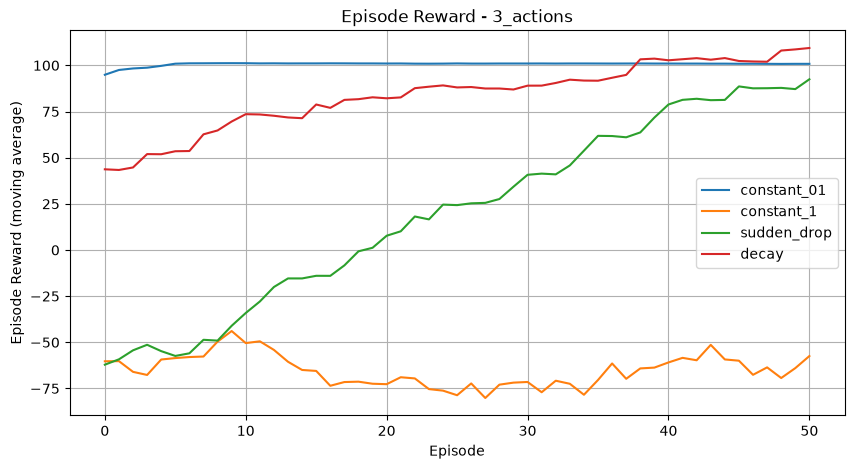

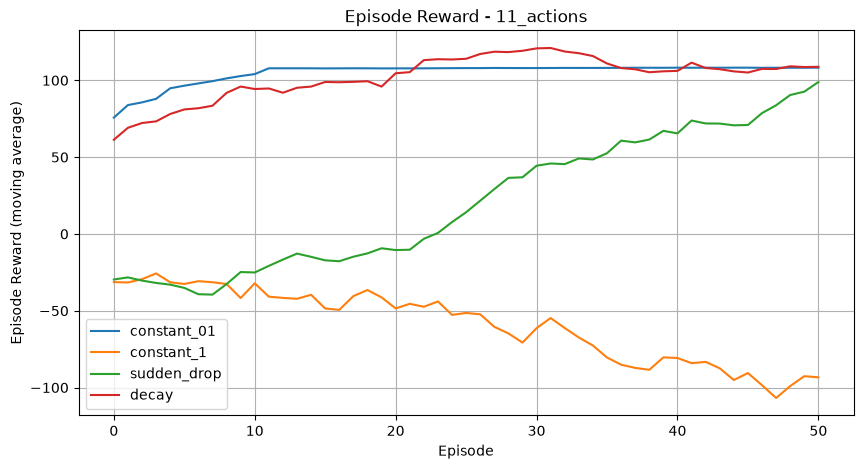

In [12]:
for action_space_name in action_spaces:
    plt.figure(figsize=(10, 5))

    for strategy in strategies:
        rewards = results[action_space_name][strategy]["episode_rewards"]
        smoothed_rewards = moving_average(rewards, window=50)

        plt.plot(smoothed_rewards, label=strategy)
        
    plt.xlabel("Episode")
    plt.ylabel("Episode Reward (moving average)")
    plt.title(f"Episode Reward - {action_space_name}")
    plt.legend()
    plt.grid(True)
    plt.show()